# $\delta_{CP}$ and the shape of $P(\bar\nu_\mu\to\bar\nu_e)$ vs $L/E$

A plot of $P(\bar\nu_\mu\to\bar\nu_e)$ in vacuum vs $L/E$ can look "strange": a plateau around
$L/E \simeq 1500$ km/GeV and near-zeros where one would expect oscillation maxima.
In this notebook we

1. reproduce such a plot;
2. split the probability into an *atmospheric*, a *solar* and an *interference* term;
3. show that the parameter driving the shape is $\delta_{CP}$ (and not $\theta_{23}$);
4. understand why: at the atmospheric maxima the interference term is $\propto \sin\delta_{CP}$.

Everything is in vacuum unless stated otherwise. Units: $L/E$ in km/GeV, $\delta_{CP}$ in degrees.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nuosc import NeutrinoOscillator, prob_vacuum, pmns_matrix, K_PHASE, NUFIT_NO

from nuosc.plotting import set_style
SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

## 0. Configuration

In [2]:
# ------------------------------------------------------------------ #
REFERENCE = dict(NUFIT_NO, delta_cp=260.0, s2_23=0.44)   # parameters that reproduce the plot
NUFIT     = dict(NUFIT_NO)                               # NuFIT 6.0, NO (delta = 212 deg, s2_23 = 0.47)
LE = np.linspace(1, 4000, 4000)                          # L/E grid [km/GeV]
E0 = 1.0                                                 # GeV (in vacuum only L/E matters)
# ------------------------------------------------------------------ #

# values read off the original plot (L/E [km/GeV], P)
ref_points = np.array([[460, 0.026], [1000, 0.004], [1500, 0.010], [2000, 0.017],
                       [2500, 0.001], [3000, 0.038], [3450, 0.001], [4000, 0.066]])

def P_mue(params, LE=LE, anti=True):
    # vacuum P(nu_mu -> nu_e) (anti=True: antineutrinos) vs L/E
    return prob_vacuum(E0, LE * E0, **params, antineutrino=anti)[1, 0]

# atmospheric oscillation maxima: Delta_31 = (2n-1) pi/2
LE_atm_max = [(2 * n - 1) * np.pi / (2 * K_PHASE * NUFIT["dm2_31"]) for n in range(1, 5)]
print("atmospheric maxima at L/E =", np.round(LE_atm_max), "km/GeV")

atmospheric maxima at L/E = [ 493. 1480. 2467. 3454.] km/GeV


## 1. Reproducing the plot

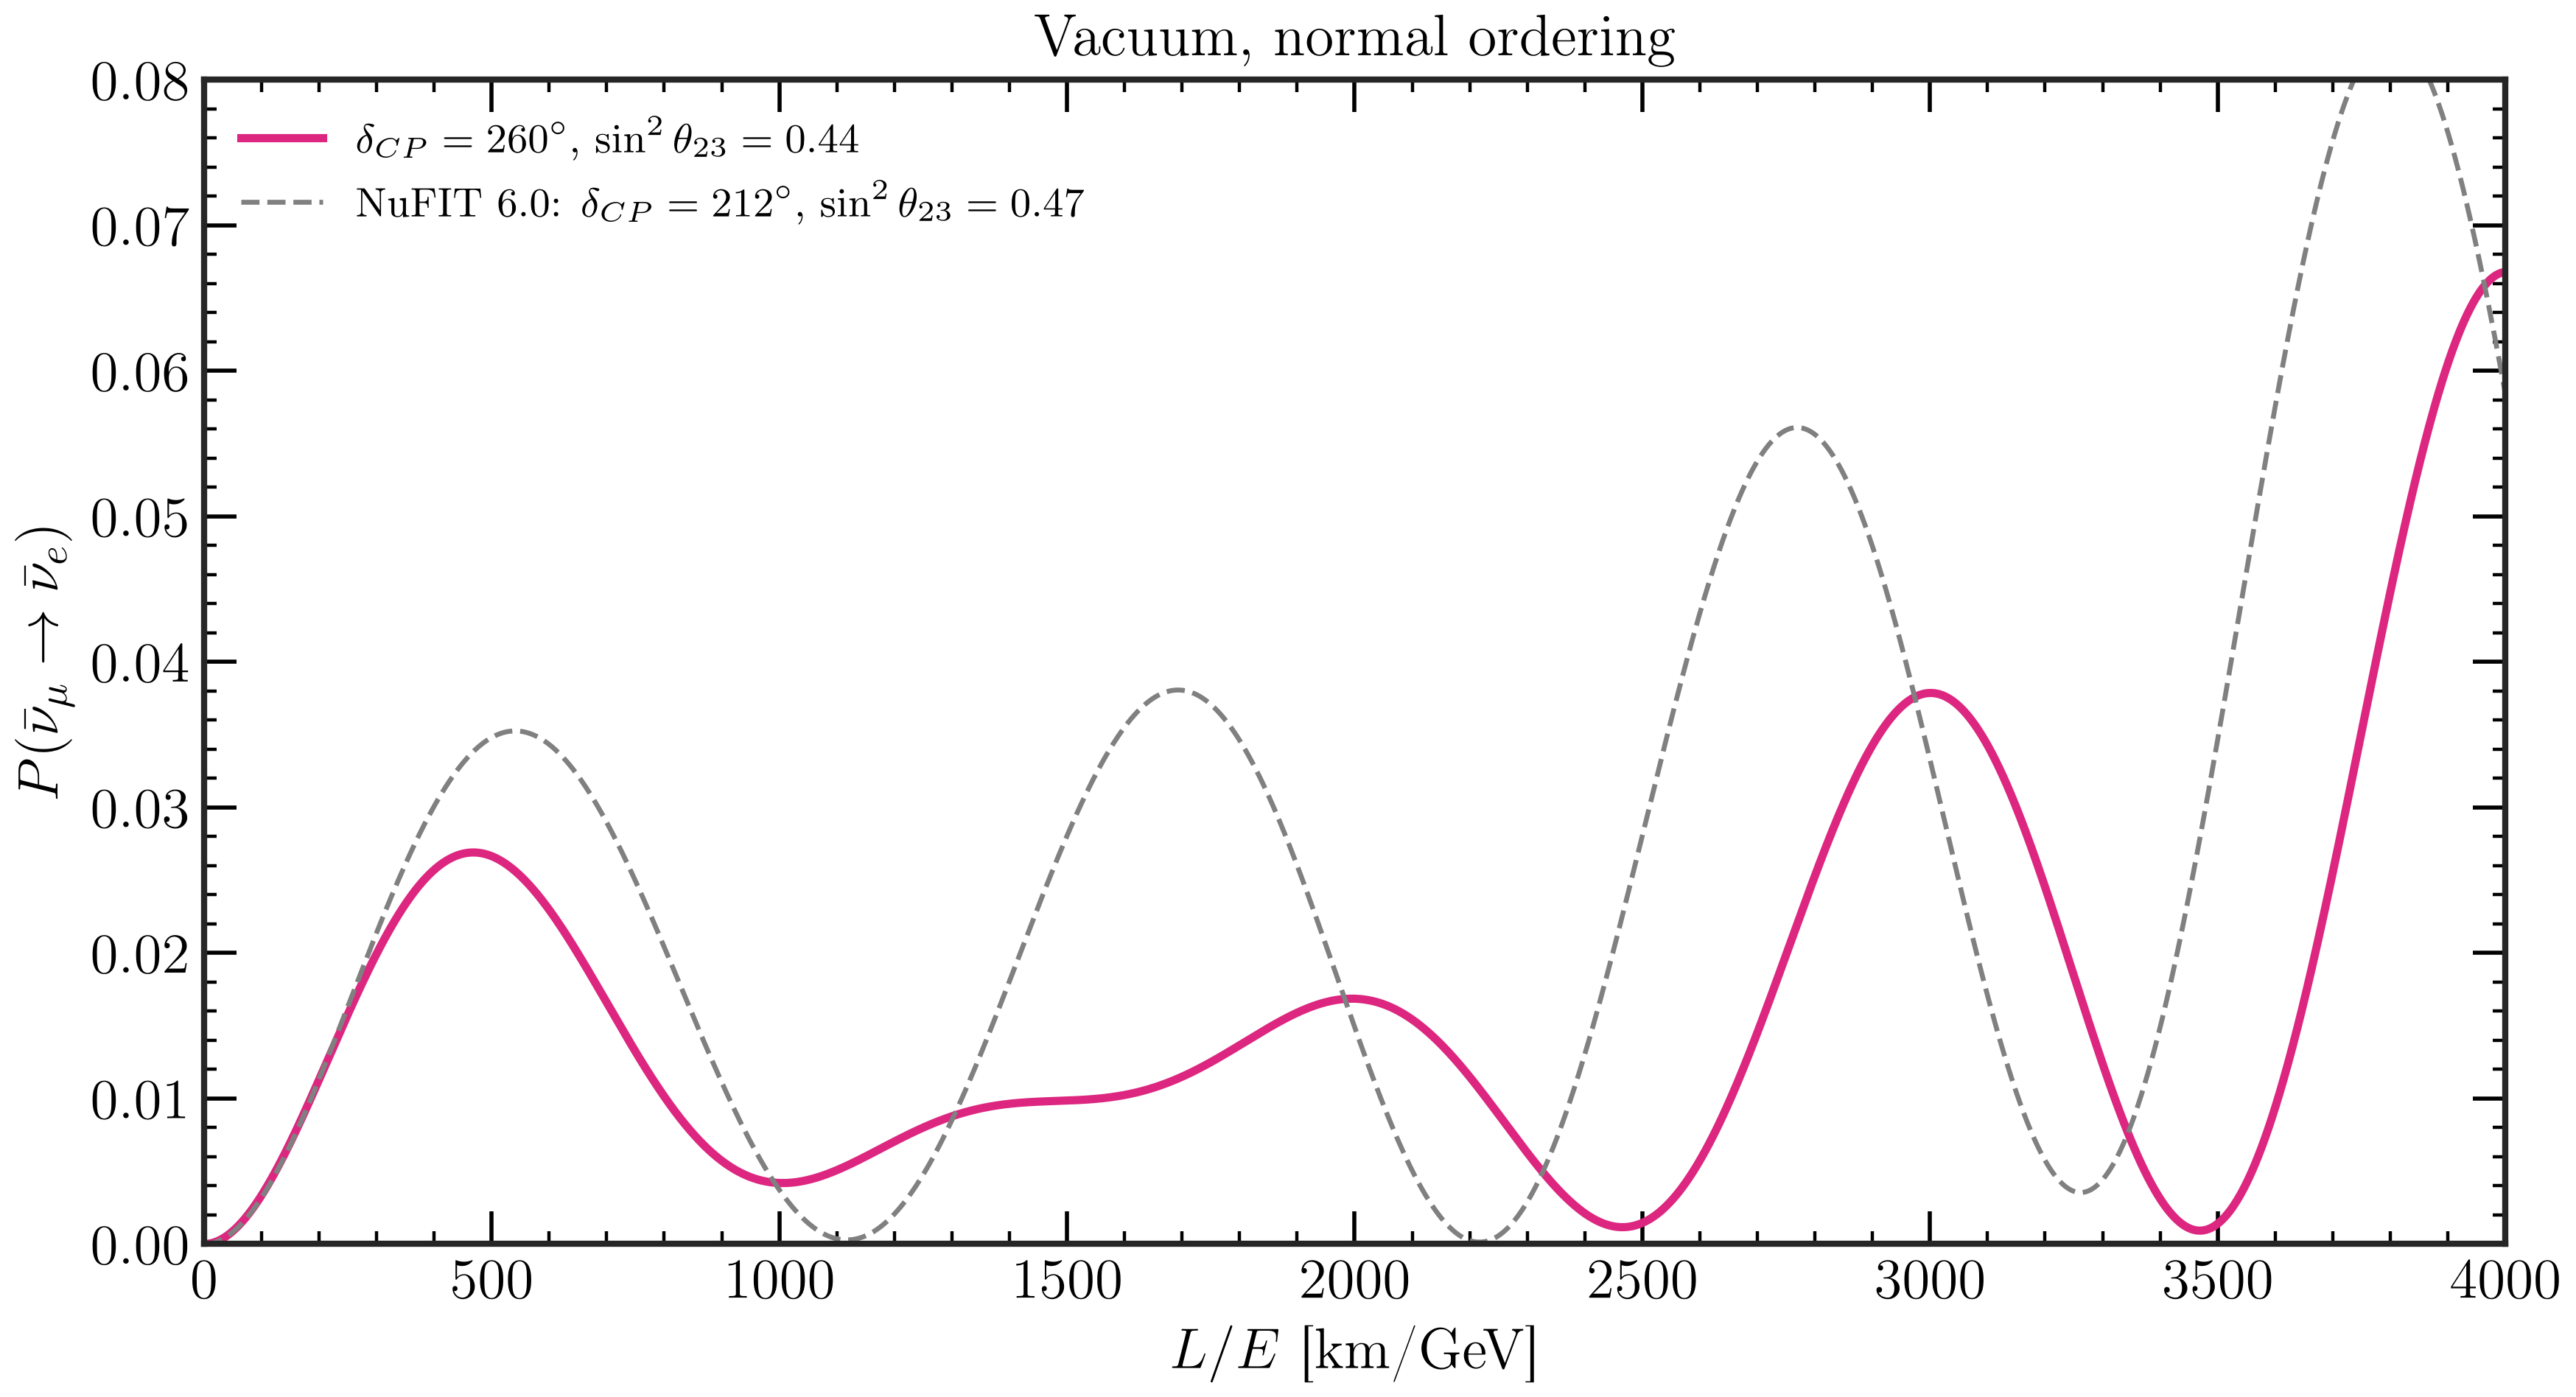

In [19]:
fig, ax = plt.subplots(figsize=(9, 5), dpi = 400)
ax.plot(LE, P_mue(REFERENCE), color=c[1], lw=2,
        label=rf"$\delta_{{CP}}={REFERENCE['delta_cp']:g}^\circ$, $\sin^2\theta_{{23}}={REFERENCE['s2_23']}$")
ax.plot(LE, P_mue(NUFIT), color="grey", ls="--",
        label=rf"NuFIT 6.0: $\delta_{{CP}}={NUFIT['delta_cp']:g}^\circ$, $\sin^2\theta_{{23}}={NUFIT['s2_23']}$")
# ax.plot(*ref_points.T, "ko", mfc="w", label="read off the original plot")
# for x in LE_atm_max:
#     ax.axvline(x, color="grey", ls=":", lw=0.8)
ax.set_xlim(0, 4000)
ax.set_ylim(0, 0.08)
ax.set_xlabel(r"$L/E$ [km/GeV]")
ax.set_ylabel(r"$P(\bar\nu_\mu\to\bar\nu_e)$")
ax.set_title("Vacuum, normal ordering")
ax.legend(fontsize="small")
plt.tight_layout()
plt.show()

## 2. Atmospheric, solar and interference terms

With $m_1$ as reference, the vacuum amplitude is a sum of two pieces,

$$
A(\nu_\mu\to\nu_e) = \underbrace{U^*_{\mu3}U_{e3}\left(e^{-2i\Delta_{31}}-1\right)}_{A_{31}\ \text{(atmospheric)}}
+ \underbrace{U^*_{\mu2}U_{e2}\left(e^{-2i\Delta_{21}}-1\right)}_{A_{21}\ \text{(solar)}},
\qquad \Delta_{ij} = 1.267\,\frac{\Delta m^2_{ij} L}{E},
$$

so that

$$
P = |A_{31}|^2 + |A_{21}|^2 + 2\,\mathrm{Re}\left(A_{31}A_{21}^*\right).
$$

* $|A_{31}|^2 = 4|U_{\mu3}U_{e3}|^2\sin^2\Delta_{31}$: fast oscillation, constant amplitude;
* $|A_{21}|^2 = 4|U_{\mu2}U_{e2}|^2\sin^2\Delta_{21}$: slow, grows with $L/E$ in this range;
* the interference term contains $\delta_{CP}$. For antineutrinos $U\to U^*$.

This decomposition is exact (we check it against `prob_vacuum`).

In [12]:
def decompose(params, LE=LE, anti=True):
    U = pmns_matrix(params["s2_12"], params["s2_13"], params["s2_23"], params["delta_cp"])
    if anti:
        U = U.conj()
    D31 = K_PHASE * params["dm2_31"] * LE
    D21 = K_PHASE * params["dm2_21"] * LE
    A31 = U[1, 2].conj() * U[0, 2] * (np.exp(-2j * D31) - 1)
    A21 = U[1, 1].conj() * U[0, 1] * (np.exp(-2j * D21) - 1)
    return dict(atm=np.abs(A31) ** 2, sol=np.abs(A21) ** 2, int=2 * np.real(A31 * np.conj(A21)))

for name, p in [("reference", REFERENCE), ("NuFIT 6.0", NUFIT)]:
    t = decompose(p)
    print(f"{name:10s}: max |sum - prob_vacuum| = {np.abs(t['atm'] + t['sol'] + t['int'] - P_mue(p)).max():.1e}")

reference : max |sum - prob_vacuum| = 2.2e-16
NuFIT 6.0 : max |sum - prob_vacuum| = 2.5e-16


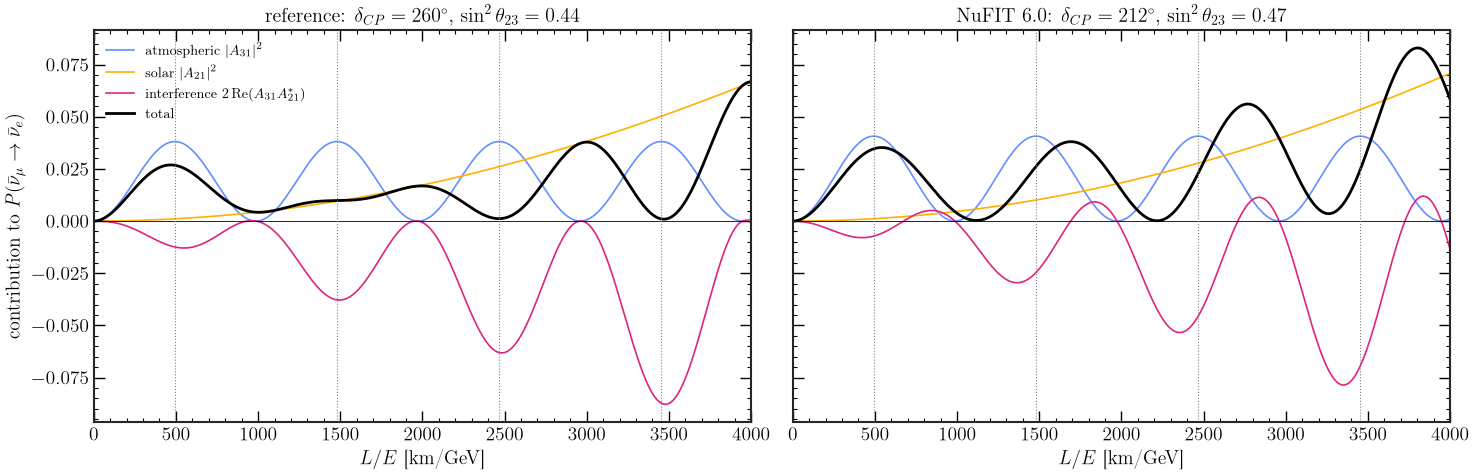

   L/E      atm      sol      int    total   (reference)
   500   0.0381   0.0011  -0.0125   0.0267
  1000   0.0001   0.0044  -0.0002   0.0042
  1500   0.0380   0.0098  -0.0379   0.0099
  2000   0.0003   0.0173  -0.0007   0.0169
  2500   0.0377   0.0268  -0.0630   0.0015
  3000   0.0006   0.0382  -0.0010   0.0379
  3500   0.0373   0.0515  -0.0874   0.0014


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (name, p) in zip(axes, [("reference", REFERENCE), ("NuFIT 6.0", NUFIT)]):
    t = decompose(p)
    ax.plot(LE, t["atm"], color=c[0], label=r"atmospheric $|A_{31}|^2$")
    ax.plot(LE, t["sol"], color=c[2], label=r"solar $|A_{21}|^2$")
    ax.plot(LE, t["int"], color=c[1], label=r"interference $2\,\mathrm{Re}(A_{31}A_{21}^*)$")
    ax.plot(LE, t["atm"] + t["sol"] + t["int"], color="k", lw=2, label="total")
    ax.axhline(0, color="k", lw=0.6)
    for x in LE_atm_max:
        ax.axvline(x, color="grey", ls=":", lw=0.8)
    ax.set_xlim(0, 4000)
    ax.set_xlabel(r"$L/E$ [km/GeV]")
    ax.set_title(rf"{name}: $\delta_{{CP}}={p['delta_cp']:g}^\circ$, $\sin^2\theta_{{23}}={p['s2_23']}$")
axes[0].set_ylabel(r"contribution to $P(\bar\nu_\mu\to\bar\nu_e)$")
axes[0].legend(fontsize="small")
plt.tight_layout()
plt.show()

t = decompose(REFERENCE)
print(f"{'L/E':>6s} {'atm':>8s} {'sol':>8s} {'int':>8s} {'total':>8s}   (reference)")
for x in [500, 1000, 1500, 2000, 2500, 3000, 3500]:
    i = np.argmin(np.abs(LE - x))
    print(f"{x:6d} {t['atm'][i]:8.4f} {t['sol'][i]:8.4f} {t['int'][i]:8.4f} {t['atm'][i] + t['sol'][i] + t['int'][i]:8.4f}")

**Reading the plot (reference parameters):**

* at the atmospheric maxima (≈ 495, 1480, 2465, 3455 km/GeV) the interference term is large and
  negative, and its size grows with $L/E$: at 1480 it cancels the atmospheric term and only the solar
  term survives (the *plateau*); at 2465 and 3455 it cancels atmospheric **and** solar terms and the
  total is almost zero;
* at the atmospheric minima (≈ 990, 1980, 2970 km/GeV) both the atmospheric and the interference
  terms vanish and only the solar term is left: the "peaks" at 2000 and 3000 are really
  *atmospheric minima*!
* with NuFIT 6.0 the cancellation is only partial and the usual oscillation pattern survives.

## 3. Which parameter drives the difference?

Start from NuFIT 6.0 and change **one parameter at a time**.

                                 rms deviation from the original plot
NuFIT 6.0                        0.0147
only s2_23 = 0.44                0.0139
only delta = 260                 0.0019
only delta = 270                 0.0017
delta = 260 and s2_23 = 0.44     0.0005


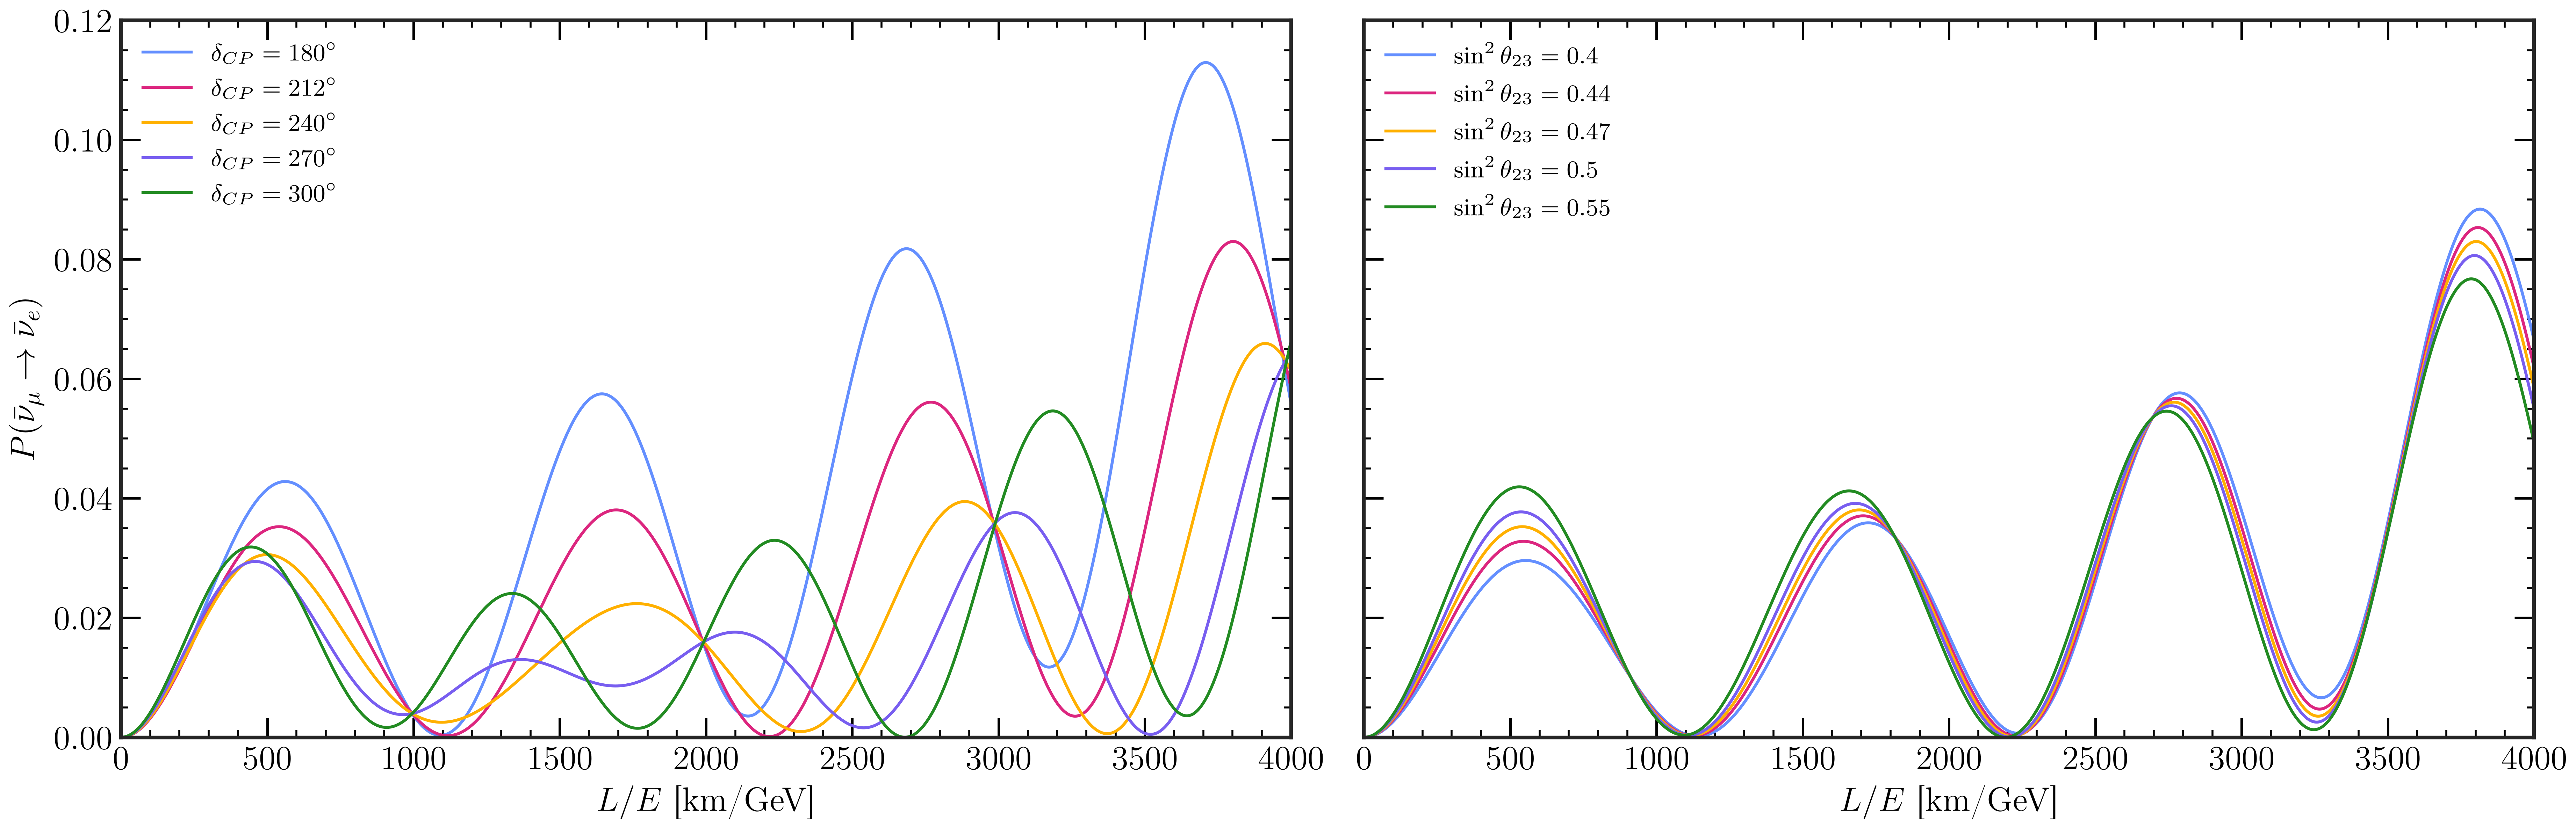

In [21]:
def rms_to_ref(params):
    return np.sqrt(np.mean((P_mue(params, ref_points[:, 0]) - ref_points[:, 1]) ** 2))

tests = [("NuFIT 6.0", {}),
         ("only s2_23 = 0.44", dict(s2_23=0.44)),
         ("only delta = 260", dict(delta_cp=260)),
         ("only delta = 270", dict(delta_cp=270)),
         ("delta = 260 and s2_23 = 0.44", dict(delta_cp=260, s2_23=0.44))]
print(f"{'':32s} rms deviation from the original plot")
for name, kw in tests:
    print(f"{name:32s} {rms_to_ref(dict(NUFIT, **kw)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, dpi = 500)
for i, d in enumerate([180, 212, 240, 270, 300]):
    axes[0].plot(LE, P_mue(dict(NUFIT, delta_cp=d)), color=c[i], label=rf"$\delta_{{CP}}={d}^\circ$")
# axes[0].set_title(r"vary $\delta_{CP}$ ($\sin^2\theta_{23}=0.47$)")
for i, s in enumerate([0.40, 0.44, 0.47, 0.50, 0.55]):
    axes[1].plot(LE, P_mue(dict(NUFIT, s2_23=s)), color=c[i], label=rf"$\sin^2\theta_{{23}}={s}$")
# axes[1].set_title(r"vary $\sin^2\theta_{23}$ ($\delta_{CP}=212^\circ$)")
for ax in axes:
    # ax.plot(*ref_points.T, "ko", mfc="w", ms=5)
    ax.set_xlim(0, 4000); ax.set_ylim(0, 0.12)
    ax.set_xlabel(r"$L/E$ [km/GeV]")
    ax.legend(fontsize="small")
axes[0].set_ylabel(r"$P(\bar\nu_\mu\to\bar\nu_e)$")
plt.tight_layout()
plt.show()

### 3a. The full picture: $\delta_{CP}$ vs $\sin^2\theta_{23}$

Agreement with the original plot (rms deviation) on a grid of $(\delta_{CP}, \sin^2\theta_{23})$.
The good region is a narrow vertical band: $\delta_{CP}$ is pinned to $\approx 240^\circ$–$290^\circ$, while
$\sin^2\theta_{23}$ can move a lot (≈ 0.37–0.52) without spoiling the agreement.

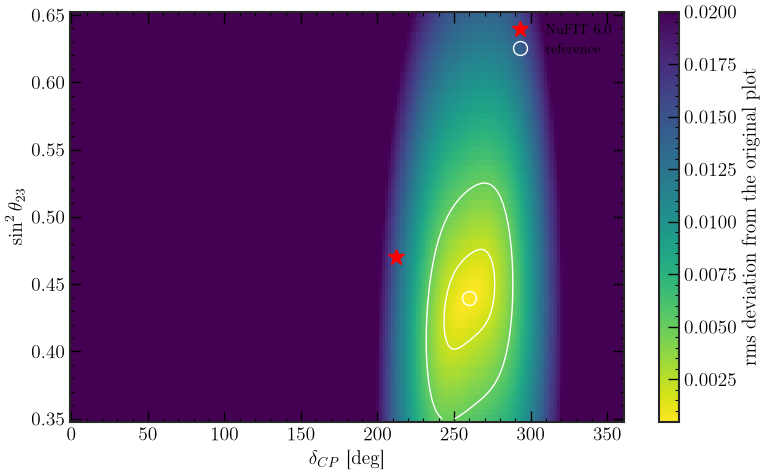

In [16]:
deltas = np.linspace(0, 360, 181)
s23s = np.linspace(0.35, 0.65, 61)
rms = np.array([[rms_to_ref(dict(NUFIT, delta_cp=d, s2_23=s)) for d in deltas] for s in s23s])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(deltas, s23s, rms, shading="auto", cmap="viridis_r", vmax=0.02)
ax.contour(deltas, s23s, rms, levels=[0.002, 0.005], colors="w", linewidths=1)
ax.plot(NUFIT["delta_cp"], NUFIT["s2_23"], "r*", ms=12, label="NuFIT 6.0")
ax.plot(REFERENCE["delta_cp"], REFERENCE["s2_23"], "wo", mfc="none", ms=10, label="reference")
ax.set_xlabel(r"$\delta_{CP}$ [deg]")
ax.set_ylabel(r"$\sin^2\theta_{23}$")
fig.colorbar(im, label="rms deviation from the original plot")
ax.legend(fontsize="small")
plt.tight_layout()
plt.show()

## 4. Why $\sin\delta_{CP}$?

At an atmospheric maximum, $\Delta_{31} = (2n-1)\pi/2$, so $e^{-2i\Delta_{31}} - 1 = -2$ (the same for every $n$).
Writing $e^{-2i\Delta_{21}}-1 = -2i\,\sin\Delta_{21}\,e^{-i\Delta_{21}}$ and $W_k = U^*_{\mu k}U_{ek}$, the
interference term at the maximum is, exactly,

$$
2\,\mathrm{Re}(A_{31}A_{21}^*) = 8\sin\Delta_{21}\left[\cos\Delta_{21}\,\mathrm{Im}(W_3W_2^*)
+ \sin\Delta_{21}\,\mathrm{Re}(W_3W_2^*)\right].
$$

* $\mathrm{Im}(W_3W_2^*) = \pm J$, the Jarlskog invariant, $J \propto \sin\delta_{CP}$; its sign flips between
  neutrinos and antineutrinos. This is the dominant piece.
* $\mathrm{Re}(W_3W_2^*)$ contains a $\cos\delta_{CP}$ term, but it is multiplied by $\sin^2\Delta_{21}$ and is
  therefore suppressed at these $L/E$ ($\Delta_{21}\approx 0.05$–$0.3$).

The prefactor $\sin\Delta_{21}$ grows with $L/E$: that is why the cancellation gets stronger at the
2nd, 3rd, 4th maximum.
Below: the interference term at the atmospheric maxima vs $\delta_{CP}$, compared with a pure $\sin\delta_{CP}$ shape.

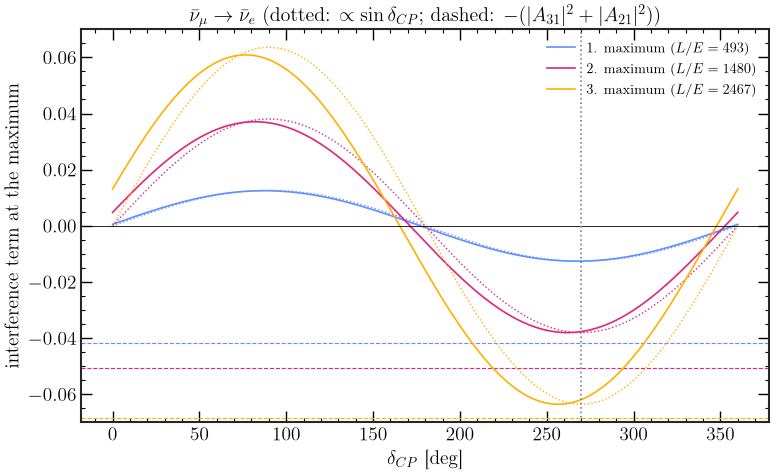

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
d = np.linspace(0, 360, 361)
for n, x in enumerate(LE_atm_max[:3], start=1):
    I = np.array([decompose(dict(NUFIT, delta_cp=di), LE=np.array([x]))["int"][0] for di in d])
    amp = np.abs(I).max()
    ax.plot(d, I, color=c[n - 1], label=rf"{n}. maximum ($L/E={x:.0f}$)")
    ax.plot(d, amp * np.sin(np.deg2rad(d)), color=c[n - 1], ls=":", lw=1)
    t0 = decompose(dict(NUFIT), LE=np.array([x]))          # atm and sol do not depend on delta
    ax.axhline(-(t0["atm"][0] + t0["sol"][0]), color=c[n - 1], ls="--", lw=0.8)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(270, color="grey", ls=":")
ax.set_xlabel(r"$\delta_{CP}$ [deg]")
ax.set_ylabel(r"interference term at the maximum")
ax.set_title(r"$\bar\nu_\mu\to\bar\nu_e$ (dotted: $\propto\sin\delta_{CP}$; dashed: $-(|A_{31}|^2+|A_{21}|^2)$)")
ax.legend(fontsize="small")
plt.tight_layout()
plt.show()

$|A_{31}|^2$ and $|A_{21}|^2$ do not depend on $\delta_{CP}$ (dashed line: $-(|A_{31}|^2+|A_{21}|^2)$).
The interference is most negative near $\delta_{CP}\approx 260^\circ$–$270^\circ$ ($\approx-\pi/2$):

* at the **1st maximum** it is small, so $P$ is only slightly reduced;
* at the **2nd maximum** it cancels the atmospheric term but not the solar one, so $P$ stays at the
  solar level: this is the plateau at $L/E\approx 1500$ km/GeV;
* from the **3rd maximum** on it almost reaches the dashed line, so $P\approx 0$.

The small shift of the minimum from exactly $270^\circ$ comes from the
$\sin^2\Delta_{21}$ term, which contains $\cos\delta_{CP}$.

## 5. Neutrinos vs antineutrinos

For neutrinos $\delta_{CP}\to-\delta_{CP}$: the same $\delta_{CP}=270^\circ$ that makes the antineutrino
interference destructive makes it **constructive** for neutrinos, so there is no plateau.

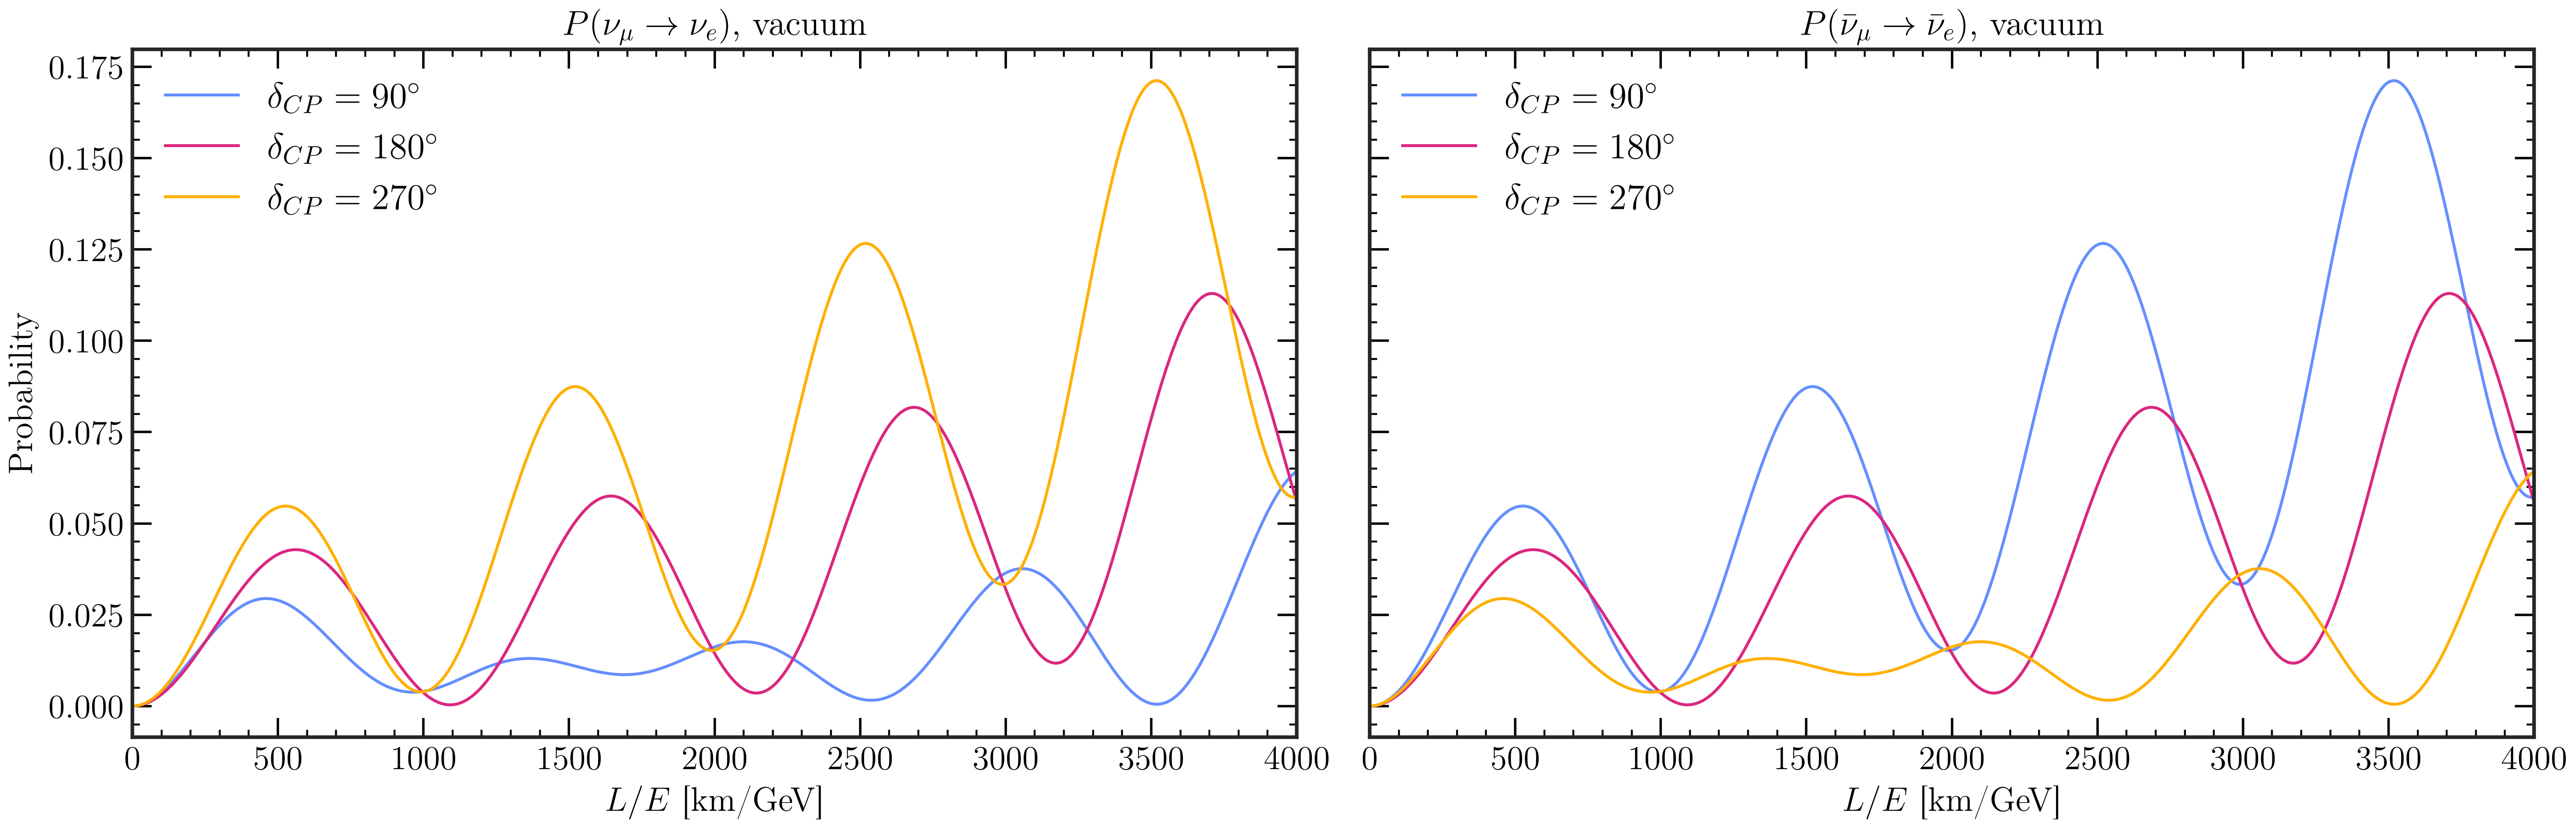

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, dpi = 400)
for ax, anti, title in [(axes[0], False, r"$P(\nu_\mu\to\nu_e)$"), (axes[1], True, r"$P(\bar\nu_\mu\to\bar\nu_e)$")]:
    for i, d in enumerate([90, 180, 270]):
        ax.plot(LE, P_mue(dict(NUFIT, delta_cp=d), anti=anti), color=c[i], label=rf"$\delta_{{CP}}={d}^\circ$")
    # for x in LE_atm_max:
    #     ax.axvline(x, color="grey", ls=":", lw=0.8)
    ax.set_xlim(0, 4000)
    ax.set_xlabel(r"$L/E$ [km/GeV]")
    ax.set_title(title + ", vacuum")
    ax.legend(fontsize=15)
axes[0].set_ylabel("Probability")
plt.tight_layout()
plt.show()

## 6. And in matter?

For a real experiment $L$ is fixed and $E$ varies. With matter effects the probability is no longer
a function of $L/E$ only; here the reference parameters for a DUNE-like baseline (1300 km) and a
T2K-like one (295 km). Around the first maximum the vacuum picture still holds qualitatively;
the plateau region ($L/E\sim 1500$ km/GeV) corresponds to $E \lesssim 1$ GeV at DUNE and $0.2$ GeV at T2K.

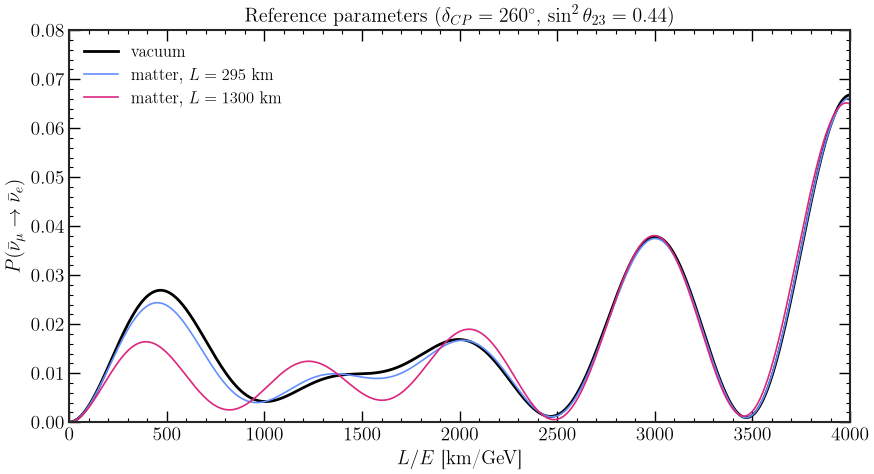

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(LE, P_mue(REFERENCE), color="k", lw=2, label="vacuum")
for i, (L, rho) in enumerate([(295, 2.6), (1300, 2.848)]):
    o = NeutrinoOscillator("NO", baseline=L, rho=rho, antineutrino=True,
                           delta_cp=REFERENCE["delta_cp"], s2_23=REFERENCE["s2_23"])
    E = L / LE
    ax.plot(LE, o.matter("mu", "e", E=E), color=c[i], label=f"matter, $L = {L}$ km")
ax.set_xlim(0, 4000); ax.set_ylim(0, 0.08)
ax.set_xlabel(r"$L/E$ [km/GeV]")
ax.set_ylabel(r"$P(\bar\nu_\mu\to\bar\nu_e)$")
ax.set_title(r"Reference parameters ($\delta_{CP}=260^\circ$, $\sin^2\theta_{23}=0.44$)")
ax.legend()
plt.tight_layout()
plt.show()